# ***Notebook Log***

Hakimi (24/5)
- Dropping irrelavant columns in Listing's dataset. It was done under *DATA PREPARATION* section.
- Handling missing values in "bathrooms", "bedrooms", "beds", "price", "review_scores_rating"
- Data splitting was unseccesful due to imbalance in class distribution. I remedy it by merging & filtering low property type class into 'class' under a sub-section of *DATA PREPARATION*
- Encoded property_type labels using LabelEncoder
- *DATA PREPROCESSING* was done using ColumnTransformer

# ***Abbreviation***

- listings: original/raw dataset.
- filtered_listings: merged property_type class dataset
- rare_classes: property_type with count lower than 5

# **1. IMPORTING LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import preprocessing
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# **2. LOADING DATASET**

In [2]:
calendar = pd.read_csv('calendar.csv')
listings = pd.read_csv('listings.csv')
reviews = pd.read_csv('reviews.csv')

In [3]:
calendar.head()

,listing_id,date,available,price
0,12147973,2017-09-05,f,NaN
1,12147973,2017-09-04,f,NaN
2,12147973,2017-09-03,f,NaN
3,12147973,2017-09-02,f,NaN
4,12147973,2017-09-01,f,NaN


In [4]:
listings.head()

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,12147973,https://www.airbnb.com/rooms/12147973,20160906204935,2016-09-07,Sunny Bungalow in the City,"Cozy, sunny, family home. Master bedroom high...",The house has an open and cozy feel at the sam...,"Cozy, sunny, family home. Master bedroom high...",none,"Roslindale is quiet, convenient and friendly. ...",...,NaN,f,NaN,NaN,f,moderate,f,f,1,NaN
1,3075044,https://www.airbnb.com/rooms/3075044,20160906204935,2016-09-07,Charming room in pet friendly apt,Charming and quiet room in a second floor 1910...,Small but cozy and quite room with a full size...,Charming and quiet room in a second floor 1910...,none,"The room is in Roslindale, a diverse and prima...",...,9.0,f,NaN,NaN,t,moderate,f,f,1,1.30
2,6976,https://www.airbnb.com/rooms/6976,20160906204935,2016-09-07,Mexican Folk Art Haven in Boston,"Come stay with a friendly, middle-aged guy in ...","Come stay with a friendly, middle-aged guy in ...","Come stay with a friendly, middle-aged guy in ...",none,The LOCATION: Roslindale is a safe and diverse...,...,10.0,f,NaN,NaN,f,moderate,t,f,1,0.47
3,1436513,https://www.airbnb.com/rooms/1436513,20160906204935,2016-09-07,Spacious Sunny Bedroom Suite in Historic Home,Come experience the comforts of home away from...,Most places you find in Boston are small howev...,Come experience the comforts of home away from...,none,Roslindale is a lovely little neighborhood loc...,...,10.0,f,NaN,NaN,f,moderate,f,f,1,1.00
4,7651065,https://www.airbnb.com/rooms/7651065,20160906204935,2016-09-07,Come Home to Boston,"My comfy, clean and relaxing home is one block...","Clean, attractive, private room, one block fro...","My comfy, clean and relaxing home is one block...",none,"I love the proximity to downtown, the neighbor...",...,10.0,f,NaN,NaN,f,flexible,f,f,1,2.25


In [5]:
reviews.columns

Index(['listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments'], dtype='object')

In [6]:
calendar.columns

Index(['listing_id', 'date', 'available', 'price'], dtype='object')

In [7]:
listings.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'summary',
       'space', 'description', 'experiences_offered', 'neighborhood_overview',
       'notes', 'transit', 'access', 'interaction', 'house_rules',
       'thumbnail_url', 'medium_url', 'picture_url', 'xl_picture_url',
       'host_id', 'host_url', 'host_name', 'host_since', 'host_location',
       'host_about', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url',
       'host_picture_url', 'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'street',
       'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'city', 'state', 'zipcode', 'market',
       'smart_location', 'country_code', 'country', 'latitude', 'longitude',
       'is_location_exact', 'property_type', 'room_type', 'accommodates',
       'bathrooms',

In [8]:
reviews.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,1178162,4724140,2013-05-21,4298113,Olivier,My stay at islam's place was really cool! Good...
1,1178162,4869189,2013-05-29,6452964,Charlotte,Great location for both airport and city - gre...
2,1178162,5003196,2013-06-06,6449554,Sebastian,We really enjoyed our stay at Islams house. Fr...
3,1178162,5150351,2013-06-15,2215611,Marine,The room was nice and clean and so were the co...
4,1178162,5171140,2013-06-16,6848427,Andrew,Great location. Just 5 mins walk from the Airp...


# **3. DATA PREPARATION**

In [9]:
# Drop irrelevant columns
irrelevant_cols = [
    'id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'summary', 'space',
    'description', 'neighborhood_overview', 'notes', 'transit', 'access', 'interaction',
    'house_rules', 'thumbnail_url', 'medium_url', 'picture_url', 'xl_picture_url',
    'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
    'host_thumbnail_url', 'host_picture_url', 'street', 'zipcode', 'market', 'country_code',
    'country', 'calendar_updated', 'calendar_last_scraped', 'license', 'jurisdiction_names']

listings = listings.drop(columns=irrelevant_cols, errors='ignore')

In [10]:
# Handle missing values
def handle_missing_data(listings):
    # Numerical columns: Impute with median
    num_cols = ['bathrooms', 'bedrooms', 'beds', 'price', 'review_scores_rating']
    for col in num_cols:
        listings[col] = listings[col].replace('[^0-9.]', '', regex=True).astype(float)  # Clean price if needed
        listings[col] = listings[col].fillna(listings[col].median())

    # Categorical columns: Impute with mode
    cat_cols = ['host_response_time', 'host_is_superhost', 'cancellation_policy']
    for col in cat_cols:
        listings[col] = listings[col].fillna(listings[col].mode()[0])

    # Drop columns with >50% missing data (e.g., 'square_feet')
    listings = listings.drop(columns=['square_feet'], errors='ignore')

    return listings

listings = handle_missing_data(listings)


In [11]:
# Define features (X) and target (y)
target = 'property_type'
features = [
    'neighbourhood_cleansed', 'room_type', 'accommodates', 'bathrooms', 'bedrooms',
    'price', 'amenities', 'cancellation_policy', 'review_scores_rating'
]

X = listings[features]
y = listings[target]


In [12]:
# Encode the target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [13]:
# Check class distribution
class_counts = listings['property_type'].value_counts()
print("Class distribution:\n", class_counts)

Class distribution:
 property_type
Apartment          2612
House               562
Condominium         231
Townhouse            54
Bed & Breakfast      41
Loft                 39
Other                17
Boat                 12
Villa                 6
Entire Floor          4
Dorm                  2
Guesthouse            1
Camper/RV             1
Name: count, dtype: int64


**Handling Property Type distribution imbalance**

In [14]:
min_samples = 10
valid_classes = class_counts[class_counts >= min_samples].index
listings_filtered = listings[listings['property_type'].isin(valid_classes)]

In [15]:
# Create a clean copy of the filtered DataFrame to avoid chained assignments
listings_filtered = listings_filtered.copy()

# Merge rare classes into "Other"
rare_classes = ['Villa', 'Boat', 'Entire Floor', 'Dorm', 'Guesthouse', 'Camper/RV', "Bed & Breakfast", "Loft", "Townhouse"]
listings_filtered.loc[
    listings_filtered['property_type'].isin(rare_classes), 'property_type'
] = 'Other'

In [16]:
# Encode the target variable
le = LabelEncoder()
y = le.fit_transform(listings_filtered['property_type'])

# Split data (stratify safely now)
X = listings_filtered[features]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

In [18]:
# Check class distribution
class_counts = listings_filtered['property_type'].value_counts()
print("Class distribution (NEW):\n", class_counts)

Class distribution (NEW):
 property_type
Apartment      2612
House           562
Condominium     231
Other           163
Name: count, dtype: int64


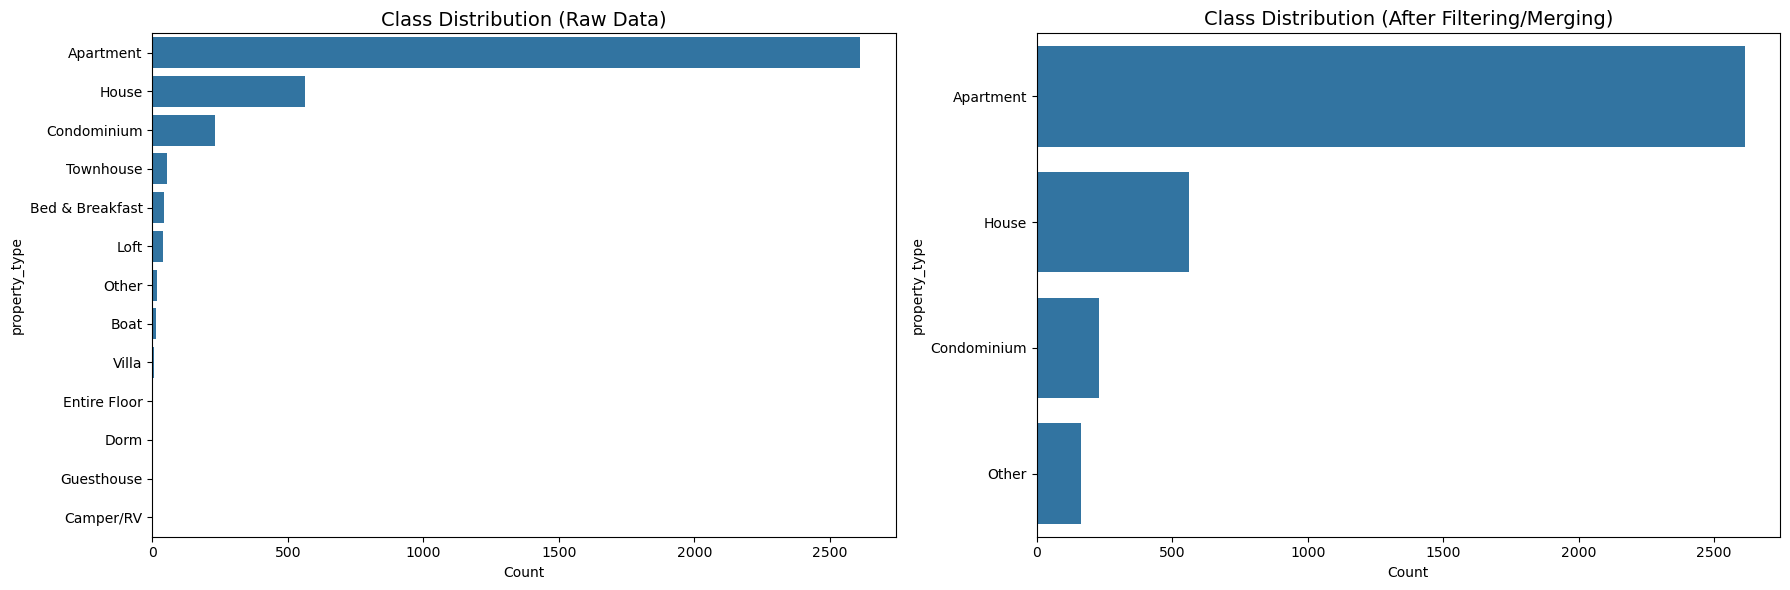

In [19]:
# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Before filtering
sns.countplot(data=listings, y='property_type', ax=axes[0], order=listings['property_type'].value_counts().index)
axes[0].set_title('Class Distribution (Raw Data)', fontsize=14)
axes[0].set_xlabel('Count')

# After filtering/merging
sns.countplot(data=listings_filtered, y='property_type', ax=axes[1], order=listings_filtered['property_type'].value_counts().index)
axes[1].set_title('Class Distribution (After Filtering/Merging)', fontsize=14)
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

C:\Users\yasse\AppData\Local\Temp\ipykernel_5016\4056200989.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_amenities, x='Count', y='Amenity', palette='Blues_d', legend=False)


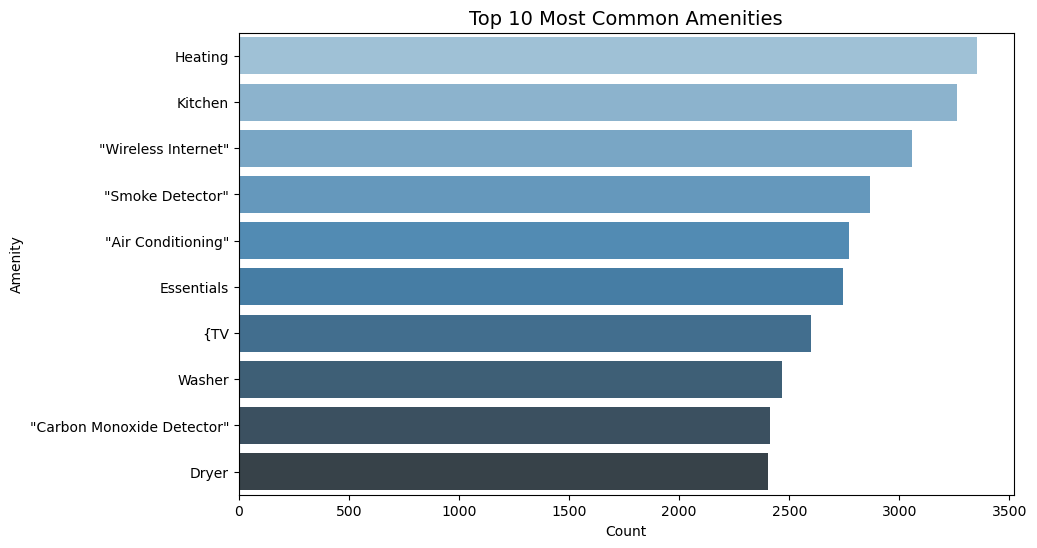

In [20]:
# Split amenities into individual items and count frequencies
all_amenities = []
for amenities_list in listings_filtered['amenities'].str.split(','):
    all_amenities.extend([amenity.strip() for amenity in amenities_list])

amenity_counts = Counter(all_amenities)
top_amenities = pd.DataFrame(amenity_counts.most_common(10), columns=['Amenity', 'Count'])

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_amenities, x='Count', y='Amenity', palette='Blues_d', legend=False)
plt.title('Top 10 Most Common Amenities', fontsize=14)
plt.show()

# **4. DATA PRE-PROCESSING**

In [21]:
features = [
    'neighbourhood_cleansed', 'room_type', 'accommodates', 'bathrooms',
    'bedrooms', 'price', 'amenities', 'cancellation_policy', 'review_scores_rating'
]
X = listings_filtered[features]
y = listings_filtered['property_type']  # Already label-encoded

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), ['accommodates', 'bathrooms', 'bedrooms', 'price', 'review_scores_rating']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['room_type', 'cancellation_policy', 'neighbourhood_cleansed']),
    ('text', TfidfVectorizer(max_features=100), 'amenities')
])

X_preprocessed = preprocessor.fit_transform(X)
X_preprocessed = X_preprocessed.toarray() if hasattr(X_preprocessed, "toarray") else X_preprocessed

le = preprocessing.LabelEncoder()
y_encoded = le.fit_transform(y)

X_trainorig, X_testorig, y_trainorig, y_testorig = train_test_split(
    X_preprocessed, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)


In [22]:
# Apply SMOTE to balance classes in training data only
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_preprocessed, y_encoded)

# Split the resampled data
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

### Logistic Regression

In [23]:
# create model
logreg = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)

# train model on resampled training data
logreg.fit(X_train, y_train)

# Predict on the test set
y_pred = logreg.predict(X_testorig)

# Evaluate the model
print("Accuracy:", accuracy_score(y_testorig, y_pred))
print("\nClassification Report:\n", classification_report(y_testorig, y_pred, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_testorig, y_pred))


Accuracy: 0.5658263305322129

Classification Report:
               precision    recall  f1-score   support

   Apartment       0.95      0.54      0.68       523
 Condominium       0.16      0.52      0.24        46
       House       0.52      0.70      0.60       112
       Other       0.19      0.67      0.30        33

    accuracy                           0.57       714
   macro avg       0.45      0.61      0.45       714
weighted avg       0.80      0.57      0.62       714


Confusion Matrix:
 [[280 109  63  71]
 [  8  24   4  10]
 [  5  16  78  13]
 [  2   4   5  22]]


### Deep Neural Network

In [24]:
X_testorig_tensor = torch.tensor(X_testorig, dtype=torch.float32)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [25]:
# convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [26]:
class DeeperAirbnbNN(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 128) # changed from 256 to 128
        self.dropout1 = nn.Dropout(0,3) # new line
        self.fc2 = nn.Linear(128, 64) # chaned from (256, 128) to (128, 64)
        self.dropout2 = nn.Dropout(0,3) # new line
        self.fc3 = nn.Linear(64, 32) # chaned from (128, 64) to (64, 32)
        # self.fc4 = nn.Linear(64, 32)
        self.output = nn.Linear(32, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = F.relu(self.fc3(x))
        # x = F.relu(self.fc4(x))
        return self.output(x)


input_dim = X_train.shape[1]
output_dim = len(le.classes_)  # number of property types

model = DeeperAirbnbNN(input_size=input_dim, output_size=output_dim)


In [27]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005) # changed fro, 0.001 to 0.0005

# training loop
n_epochs = 50 # changed from 100 to 50
for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {total_loss:.4f}")


Epoch 1/50, Loss: 168.2457
Epoch 2/50, Loss: 133.6498
Epoch 3/50, Loss: 113.5557
Epoch 4/50, Loss: 97.2415
Epoch 5/50, Loss: 84.7484
Epoch 6/50, Loss: 74.1699
Epoch 7/50, Loss: 64.9056
Epoch 8/50, Loss: 57.7733
Epoch 9/50, Loss: 51.0704
Epoch 10/50, Loss: 46.2105
Epoch 11/50, Loss: 42.3552
Epoch 12/50, Loss: 38.5969
Epoch 13/50, Loss: 35.3668
Epoch 14/50, Loss: 32.5054
Epoch 15/50, Loss: 30.0481
Epoch 16/50, Loss: 28.1696
Epoch 17/50, Loss: 25.9272
Epoch 18/50, Loss: 23.8766
Epoch 19/50, Loss: 22.4158
Epoch 20/50, Loss: 21.0688
Epoch 21/50, Loss: 19.9994
Epoch 22/50, Loss: 18.6452
Epoch 23/50, Loss: 17.5983
Epoch 24/50, Loss: 16.4601
Epoch 25/50, Loss: 15.4958
Epoch 26/50, Loss: 14.8687
Epoch 27/50, Loss: 13.5889
Epoch 28/50, Loss: 13.7524
Epoch 29/50, Loss: 12.4309
Epoch 30/50, Loss: 11.7614
Epoch 31/50, Loss: 11.3913
Epoch 32/50, Loss: 10.2714
Epoch 33/50, Loss: 9.7298
Epoch 34/50, Loss: 9.0816
Epoch 35/50, Loss: 8.6483
Epoch 36/50, Loss: 8.7526
Epoch 37/50, Loss: 8.2293
Epoch 38/50,

In [28]:
X_testorig_tensor.shape

torch.Size([714, 114])

In [29]:
from sklearn.metrics import classification_report

model.eval()
with torch.no_grad():
    y_pred_logits = model(X_testorig_tensor)
    y_pred = torch.argmax(y_pred_logits, dim=1).numpy()

print(classification_report(y_testorig, y_pred, target_names=le.classes_))


              precision    recall  f1-score   support

   Apartment       1.00      0.85      0.91       523
 Condominium       0.59      1.00      0.74        46
       House       0.75      0.97      0.84       112
       Other       0.72      1.00      0.84        33

    accuracy                           0.88       714
   macro avg       0.76      0.95      0.83       714
weighted avg       0.92      0.88      0.89       714



In [30]:
y_test

array([1, 3, 1, ..., 1, 2, 0])

In [31]:
model.eval()

DeeperAirbnbNN(
  (fc1): Linear(in_features=114, out_features=128, bias=True)
  (dropout1): Dropout(p=0, inplace=3)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (dropout2): Dropout(p=0, inplace=3)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=4, bias=True)
)